# ORT: Zwaartekracht Gevorderd

**Hoofdstuk 12, deel 2 | §12.15–12.21, §12.26–12.27 | Formules 40–65, 82–103**

Dit notebook behandelt de gevorderde zwaartekrachtseffecten:
Reissner-Nordström (geladen massa), Shapiro-vertraging, geodetische precessie,
fotonsfeer, Einstein-ringen, de S2-ster, zwaartekrachtsgolven en de Kerr-metriek.

---

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / 'shared'))
from ort_core import *
from ort_plots import (cosmological_shell_diagram, gw_strain_plot, gw_inspiral_interactive,
    kerr_geometry_plot, kerr_frame_drag_field, isco_comparison_plot, comparison_table,
    photon_sphere_shadow, einstein_ring_plot)
import matplotlib.pyplot as plt
import math
import numpy as np
%matplotlib inline

## §12.15 — Reissner-Nordström (geladen massa)

De metriekfunctie met ladingsterm:

$$f(r) = 1 - \frac{r_s}{r} + \frac{r_Q^2}{r^2} \qquad (40)$$

met $r_Q^2 = k_e Q^2 G / c^4$.

**Twee horizonten**:

$$r_{\pm} = \frac{r_s \pm \sqrt{r_s^2 - 4r_Q^2}}{2} \qquad (42)$$

**Extremale lading** ($r_+ = r_-$):

$$Q_{ext} = c^2 \sqrt{\frac{r_s^2}{4 k_e G}} \qquad (43)$$

Lading **counteract** zwaartekracht: lichtafbuiging, precissie, $v_{grav}$ nemen af.

In [2]:
# Reissner-Nordström: vergelijking Schwarzschild vs geladen
M_BH = 10 * M_SUN
bh_sch = GravityModel(M_BH)               # Ongeladen
Q_ext = bh_sch.extremal_charge()
bh_half = GravityModel(M_BH, charge=0.5 * Q_ext)  # Halve extremale lading
bh_ext = GravityModel(M_BH, charge=0.99 * Q_ext)  # Bijna extremaal

print(f"=== Reissner-Nordström (10 M☉) ===")
print(f"r_s = {bh_sch.rs:.3e} m")
print(f"Q_ext = {Q_ext:.3e} C")
print()

for label, model in [("Q = 0 (Schwarzschild)", bh_sch),
                      ("Q = 0.5 Q_ext", bh_half),
                      ("Q = 0.99 Q_ext", bh_ext)]:
    r_plus = model.r_plus
    r_minus = model.r_minus
    print(f"--- {label} ---")
    print(f"  r+ = {r_plus:.3e} m = {r_plus/bh_sch.rs:.4f} r_s")
    print(f"  r- = {r_minus:.3e} m = {r_minus/bh_sch.rs:.4f} r_s")
    # Lichtafbuiging bij b = 10 r_s
    b = 10 * bh_sch.rs
    alpha = model.light_deflection_arcsec(b)
    print(f"  Lichtafbuiging (b=10r_s): {alpha:.6f}\"")
    print()

=== Reissner-Nordström (10 M☉) ===
r_s = 2.954e+04 m
Q_ext = 1.714e+21 C

--- Q = 0 (Schwarzschild) ---
  r+ = 2.954e+04 m = 1.0000 r_s
  r- = 0.000e+00 m = 0.0000 r_s
  Lichtafbuiging (b=10r_s): 41252.961249"

--- Q = 0.5 Q_ext ---
  r+ = 2.756e+04 m = 0.9330 r_s
  r- = 1.979e+03 m = 0.0670 r_s
  Lichtafbuiging (b=10r_s): 40949.211249"

--- Q = 0.99 Q_ext ---
  r+ = 1.685e+04 m = 0.5705 r_s
  r- = 1.269e+04 m = 0.4295 r_s
  Lichtafbuiging (b=10r_s): 40062.139749"



## §12.16 — Shapiro-vertraging

De vierde klassieke test van de ART. Een signaal nabij een massa doet er langer over:

$$\Delta t = \frac{r_s}{c} \cdot \ln\!\left(\frac{4 r_1 r_2}{b^2}\right) \qquad (49)$$

Met ladingscorrectie (RN):

$$\Delta t_{RN} = \frac{r_s}{c} \cdot \ln\!\left(\frac{4 r_1 r_2}{b^2}\right) - \frac{\pi r_Q^2}{c \cdot b} \qquad (50)$$

Net als bij lichtafbuiging: **50/50 temporeel + ruimtelijk**.

In [3]:
# Shapiro-vertraging: Cassini-meting
b_cassini = 1.6 * R_SUN       # impactparameter
r_earth = A_EARTH_ORBIT        # Aarde-Zon afstand
r_saturn = R_SATURN_ORBIT      # Saturnus-Zon afstand

delay = SUN.shapiro_delay(r_earth, r_saturn, b_cassini)
delay_us = delay * 1e6
delay_roundtrip = SUN.shapiro_delay_roundtrip(r_earth, r_saturn, b_cassini)

# Alleen temporeel (helft)
delay_half = SUN.half_shapiro_delay(r_earth, r_saturn, b_cassini)

print("=== Shapiro-vertraging (Cassini) ===")
print(f"b = {b_cassini/R_SUN:.1f} R_zon = {b_cassini:.3e} m")
print(f"r₁ (Aarde)   = {r_earth:.3e} m")
print(f"r₂ (Saturnus) = {r_saturn:.3e} m")
print()
print(f"Alleen temporeel (helft): {delay_half*1e6:.2f} µs")
print(f"Volledig (temp+ruimt):    {delay_us:.2f} µs")
print(f"Rondtrip:                 {delay_roundtrip*1e6:.2f} µs")
print()
print(f"Cassini resultaat (2003): γ = 1 + (2.1 ± 2.3) × 10⁻⁵")

=== Shapiro-vertraging (Cassini) ===
b = 1.6 R_zon = 1.113e+09 m
r₁ (Aarde)   = 1.496e+11 m
r₂ (Saturnus) = 1.434e+12 m

Alleen temporeel (helft): 66.26 µs
Volledig (temp+ruimt):    132.51 µs
Rondtrip:                 265.03 µs

Cassini resultaat (2003): γ = 1 + (2.1 ± 2.3) × 10⁻⁵


## §12.17 — Geodetische (de Sitter) precessie

De draaiingsas van een gyroscoop precideert in een baan rond een massa:

$$\Delta\theta = 2\pi \left[1 - \sqrt{1 - \frac{3r_s}{2r}}\right] \qquad (51)$$

Zwak-veldbenadering:

$$\Delta\theta \approx \frac{3\pi}{2} \cdot \frac{r_s}{r} = \frac{3\pi GM}{rc^2} \qquad (52)$$

Met ladingscorrectie (RN):

$$\Delta\theta = 2\pi \left[1 - \sqrt{1 - \frac{3r_s}{2r} + \frac{2r_Q^2}{r^2}}\right] \qquad (53)$$

### De 1/3 + 2/3 verdeling

In tegenstelling tot de andere effecten (50/50):
- **1/3 — Thomas-precessie** (SRT, temporeel)
- **2/3 — Ruimtekromming** (GR, ruimtelijk)

| Effect | Temporeel | Ruimtelijk | Verhouding |
|--------|-----------|------------|------------|
| Lichtafbuiging | 50% | 50% | 1:1 |
| Shapiro-vertraging | 50% | 50% | 1:1 |
| Baanprecissie | 50% | 50% | 1:1 |
| Geodetische precessie | 33% | 67% | 1:2 |

In [4]:
# Geodetische precessie: Gravity Probe B
gpb_period = EARTH.orbital_period(GPB_ORBIT_RADIUS)
gpb_prec = EARTH.geodetic_precession(GPB_ORBIT_RADIUS)
gpb_mas_yr = EARTH.geodetic_precession_mas_per_year(GPB_ORBIT_RADIUS, gpb_period)

print("=== Geodetische precessie — Gravity Probe B ===")
print(f"Baanhoogte: 642 km (r = {GPB_ORBIT_RADIUS:.3e} m)")
print(f"Baanperiode: {gpb_period:.1f} s = {gpb_period/60:.1f} min")
print(f"\nΔθ per omloop       = {gpb_prec:.6e} rad")
print(f"Δθ per jaar         = {gpb_mas_yr:.1f} mas/jr")
print(f"\nVoorspeld (ART):   6606.1 mas/jr")
print(f"Gemeten (GP-B):    6601.8 ± 18.3 mas/jr")
print()

# 1/3 + 2/3 verdeling
thomas = gpb_mas_yr / 3
curvature = 2 * gpb_mas_yr / 3
print(f"Thomas-bijdrage (1/3):     {thomas:.1f} mas/jr")
print(f"Krommingsbijdrage (2/3):   {curvature:.1f} mas/jr")

=== Geodetische precessie — Gravity Probe B ===
Baanhoogte: 642 km (r = 7.013e+06 m)
Baanperiode: 5844.8 s = 97.4 min

Δθ per omloop       = 5.960071e-09 rad
Δθ per jaar         = 6637.5 mas/jr

Voorspeld (ART):   6606.1 mas/jr
Gemeten (GP-B):    6601.8 ± 18.3 mas/jr

Thomas-bijdrage (1/3):     2212.5 mas/jr
Krommingsbijdrage (2/3):   4425.0 mas/jr


## §12.18 — Modelvergelijking

Zes modellen, tien effecten — de **eerlijkheidstabel**.

Legenda: **✓** correct, **½** halve waarde, **✗** geen voorspelling, **—** n.v.t., **⚠** beperkt

In [5]:
# Modelvergelijkingstabel
comparison_table(lang='nl')

Effect,Newton,Michell/Laplace,Soldner/Einstein 1911,ART (1915),SpaceTime,Thomas
Gravitationele tijddilatatie,✗,✗,✗,✓,✓,—
Gravitationele roodverschuiving,✗,✗,✗,✓,✓,—
Lichtafbuiging,✗,✗,½,✓,✓,—
Baanprecissie,✗,✗,✗,✓,✓,—
Shapiro-vertraging,✗,✗,½,✓,✓,—
Geodetische precessie,✗,✗,✗,✓,✓,⅓
Eventhorizon,v_esc,r=2GM/c²,—,✓,✓,—
BH-interieur,—,—,—,✓,✓,—
Frame-dragging,✗,✗,✗,✓,✓,—
Zwaartekrachtsgolven,✗,✗,✗,✓,✓,—


## §12.19 — Fotonsfeer en zwart-gatschaduw (EHT)

De fotonsfeer is de straal waarop fotonen in een (instabiele) cirkelbaan draaien:

$$r_{foton} = \frac{3}{2} r_s = \frac{3GM}{c^2} \qquad (55)$$

Voor RN:

$$r_{foton} = \frac{3r_s + \sqrt{9r_s^2 - 32r_Q^2}}{4} \qquad (56)$$

De **schaduwstraal** (kritische impactparameter):

$$b_{crit} = \frac{r_{foton}}{\sqrt{f(r_{foton})}} \qquad (57)$$

Voor Schwarzschild: $b_{crit} = \frac{3\sqrt{3}}{2} r_s \approx 2.598\, r_s$

De hoekdiameter van de schaduw:

$$\theta_{schaduw} = \frac{2 b_{crit}}{D} \qquad (58)$$

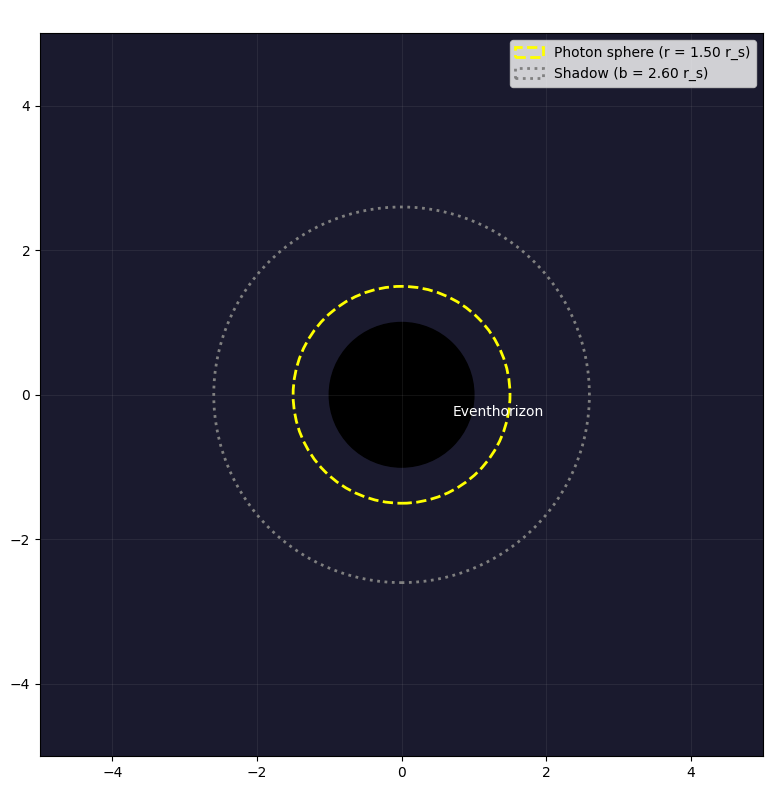

In [6]:
# Fotonsfeer en schaduw visualisatie
fig = photon_sphere_shadow(lang='nl')
plt.show()

In [7]:
# Schaduwgrootte M87* en Sgr A*
print("=== Zwart-gatschaduwen (EHT) ===")
print()

for name, model, dist in [("M87*", M87_STAR, D_M87_STAR),
                           ("Sgr A*", SGR_A_STAR, D_SGR_A_STAR)]:
    r_ph = model.photon_sphere()
    b_crit = model.shadow_radius()
    theta_uas = model.shadow_angular_diameter(dist)
    print(f"--- {name} ---")
    print(f"  Massa:        {model.mass/M_SUN:.2e} M☉")
    print(f"  Afstand:      {dist/PARSEC:.0f} pc")
    print(f"  r_s:          {model.rs:.3e} m")
    print(f"  r_foton:      {r_ph:.3e} m = {r_ph/model.rs:.3f} r_s")
    print(f"  b_crit:       {b_crit:.3e} m = {b_crit/model.rs:.3f} r_s")
    print(f"  Schaduw:      {theta_uas:.1f} µas")
    print()

print("EHT metingen:")
print("  M87*  (2019): 42 ± 3 µas")
print("  Sgr A* (2022): 51.8 ± 2.3 µas")

=== Zwart-gatschaduwen (EHT) ===

--- M87* ---
  Massa:        6.50e+09 M☉
  Afstand:      16800000 pc
  r_s:          1.920e+13 m
  r_foton:      2.880e+13 m = 1.500 r_s
  b_crit:       4.989e+13 m = 2.598 r_s
  Schaduw:      39.7 µas

--- Sgr A* ---
  Massa:        4.00e+06 M☉
  Afstand:      8178 pc
  r_s:          1.182e+10 m
  r_foton:      1.772e+10 m = 1.500 r_s
  b_crit:       3.070e+10 m = 2.598 r_s
  Schaduw:      50.2 µas

EHT metingen:
  M87*  (2019): 42 ± 3 µas
  Sgr A* (2022): 51.8 ± 2.3 µas


## §12.20 — Einstein-ringen

Bij perfecte uitlijning vormt het licht een ring met hoekstraal:

$$\theta_E = \sqrt{\frac{2r_s \cdot D_{LS}}{D_L \cdot D_S}} = \sqrt{\frac{4GM}{c^2} \cdot \frac{D_{LS}}{D_L \cdot D_S}} \qquad (60)$$

Puntmassa-versterking:

$$\mu = \frac{u^2 + 2}{u \sqrt{u^2 + 4}} \qquad (61)$$

met $u = \beta / \theta_E$ (genormaliseerde bronpositie).

In [8]:
# Einstein-ring voorbeeld
d_L = 1.0e9 * PARSEC    # 1 Gpc (lens)
d_S = 2.0e9 * PARSEC    # 2 Gpc (bron)
d_LS = 1.0e9 * PARSEC   # afstand lens-bron
lens = GravityModel(1e12 * M_SUN)  # 10^12 M_zon cluster

theta_E = lens.einstein_ring_angle_arcsec(d_L, d_S, d_LS)

print("=== Einstein-ring ===")
print(f"Lensmassa:   10¹² M☉ (galaxycluster)")
print(f"D_L = 1 Gpc, D_S = 2 Gpc, D_LS = 1 Gpc")
print(f"\nθ_E = {theta_E:.2f} boogseconden")
print()

# Versterking bij verschillende bronposities
print("Versterking bij afstand van as:")
for u in [0.1, 0.5, 1.0, 2.0, 5.0]:
    mu = GravityModel.lens_magnification(u)
    print(f"  u = {u:.1f}:  µ = {mu:.3f}")

=== Einstein-ring ===
Lensmassa:   10¹² M☉ (galaxycluster)
D_L = 1 Gpc, D_S = 2 Gpc, D_LS = 1 Gpc

θ_E = 2.02 boogseconden

Versterking bij afstand van as:
  u = 0.1:  µ = 10.037
  u = 0.5:  µ = 2.183
  u = 1.0:  µ = 1.342
  u = 2.0:  µ = 1.061
  u = 5.0:  µ = 1.003


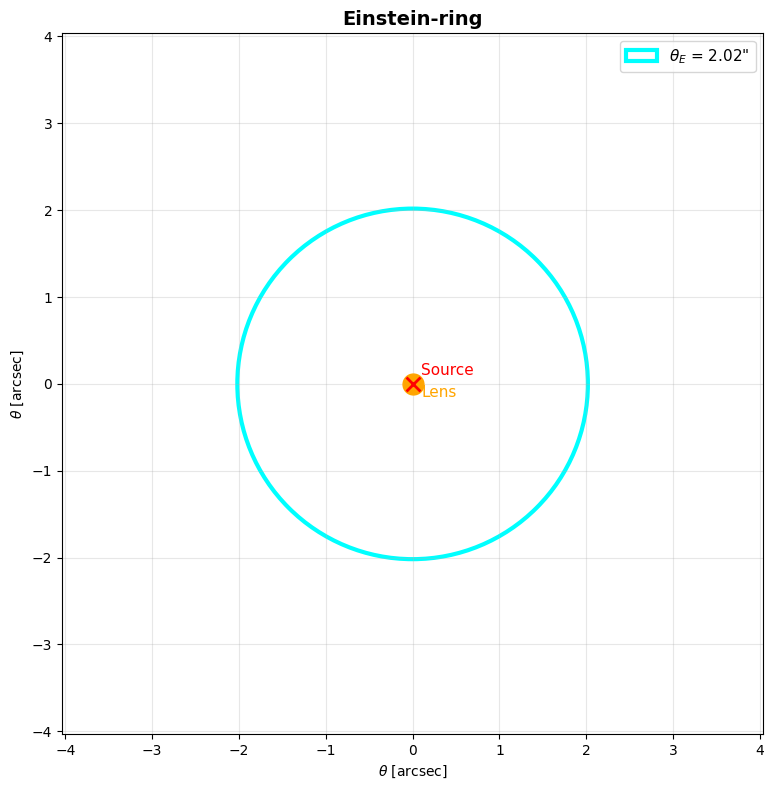

In [9]:
# Einstein-ring plot
fig = einstein_ring_plot(theta_E_arcsec=theta_E, lang='nl')
plt.show()

## §12.21 — Sterk-veld roodverschuiving: de S2-ster bij Sgr A*

De S2-ster draait in ~16 jaar rond Sgr A* ($4 \times 10^6 M_\odot$). Bij het pericenter:

**Gravitationele roodverschuiving:**
$$z_{grav} = \frac{1}{\sqrt{1 - r_s/r_p}} - 1 \approx \frac{r_s}{2r_p} \qquad (62)$$

**Transversale Dopplerverschuiving (SRT):**
$$z_{SRT} = \frac{1}{\sqrt{1 - v^2/c^2}} - 1 \approx \frac{v^2}{2c^2} \qquad (63)$$

**Gecombineerd (ORT):**
$$z_{totaal} = \frac{1}{\sqrt{f(r) - v^2/c^2}} - 1 \qquad (64)$$

**Schwarzschild-precissie van S2:**
$$\Delta\varphi = \frac{3\pi r_s}{a(1-e^2)} \approx 0.19\degree \approx 12' \text{ per omloop} \qquad (65)$$

In [10]:
# S2-ster bij Sgr A*
r_peri = GravityModel.pericenter_distance(A_S2, E_S2)
v_peri = SGR_A_STAR.pericenter_velocity(A_S2, E_S2)

print("=== S2-ster bij Sgr A* ===")
print(f"Halve grote as a  = {A_S2:.3e} m = {A_S2/1.496e11:.0f} AU")
print(f"Excentriciteit e  = {E_S2}")
print(f"Omlooptijd        = {P_S2/(365.25*86400):.2f} jaar")
print(f"Pericenterafstand = {r_peri:.3e} m = {r_peri/1.496e11:.0f} AU")
print(f"r_p / r_s         = {r_peri/SGR_A_STAR.rs:.0f}")
print(f"Pericentersnelh.  = {v_peri:.0f} m/s = {v_peri/1000:.0f} km/s = {v_peri/C:.4f} c")
print()

# Roodverschuivingen
z_grav = 1/SGR_A_STAR.time_dilation_factor(r_peri) - 1
z_srt = 1/math.sqrt(1 - (v_peri/C)**2) - 1
z_combined = SGR_A_STAR.combined_redshift(r_peri, v_peri)

print("--- Roodverschuivingen bij pericenter ---")
print(f"z_grav (gravitationeel)  = {z_grav:.4e}  (Δv = {z_grav*C/1000:.0f} km/s)")
print(f"z_SRT  (transversaal)    = {z_srt:.4e}  (Δv = {z_srt*C/1000:.0f} km/s)")
print(f"z_totaal (gecombineerd)  = {z_combined:.4e}  (Δv = {z_combined*C/1000:.0f} km/s)")
print()

# Schwarzschild-precissie
prec_s2 = SGR_A_STAR.orbital_precession(A_S2, E_S2)
prec_s2_arcmin = prec_s2 * (180/math.pi) * 60

print("--- Schwarzschild-precissie ---")
print(f"Δφ per omloop = {prec_s2:.6e} rad = {prec_s2_arcmin:.2f}' = {prec_s2*180/math.pi:.3f}°")
print()
print("GRAVITY/ESO metingen:")
print("  Roodverschuiving (2018): f = 0.88 ± 0.17 (ART: f = 1)")
print("  Precissie (2020):        f_SP = 1.10 ± 0.19 (ART: f_SP = 1)")

=== S2-ster bij Sgr A* ===
Halve grote as a  = 1.534e+14 m = 1025 AU
Excentriciteit e  = 0.8843
Omlooptijd        = 16.05 jaar
Pericenterafstand = 1.775e+13 m = 119 AU
r_p / r_s         = 1502
Pericentersnelh.  = 7508374 m/s = 7508 km/s = 0.0250 c

--- Roodverschuivingen bij pericenter ---
z_grav (gravitationeel)  = 3.3306e-04  (Δv = 100 km/s)
z_SRT  (transversaal)    = 3.1378e-04  (Δv = 94 km/s)
z_totaal (gecombineerd)  = 6.4715e-04  (Δv = 194 km/s)

--- Schwarzschild-precissie ---
Δφ per omloop = 3.330055e-03 rad = 11.45' = 0.191°

GRAVITY/ESO metingen:
  Roodverschuiving (2018): f = 0.88 ± 0.17 (ART: f = 1)
  Precissie (2020):        f_SP = 1.10 ± 0.19 (ART: f_SP = 1)


---

## Zwaartekrachtsgolven en Kerr-metriek

De volgende secties komen uit §12.26–12.27 van MODEL.md.

---

## Samenvatting

Dit notebook behandelt de gevorderde zwaartekrachtseffecten van de ORT:

| §  | Onderwerp | Formules | Status |
|---|---|---|---|
| 12.15 | Reissner-Nordström | (40)-(43) | Afgeleid |
| 12.16 | Shapiro-vertraging | (49)-(50) | Bevestigd (Cassini) |
| 12.17 | Geodetische precessie | (51)-(53) | Bevestigd (GP-B) |
| 12.18 | Modelvergelijking | — | Eerlijkheidstabel |
| 12.19 | Fotonsfeer & EHT | (55)-(58) | Bevestigd (M87*, Sgr A*) |
| 12.20 | Einstein-ringen | (60)-(61) | Waargenomen |
| 12.21 | S2-ster roodverschuiving | (62)-(65) | Bevestigd (GRAVITY) |
| 12.26 | Zwaartekrachtsgolven | (82)-(96) | Bevestigd (LIGO) |
| 12.27 | Kerr-metriek | (97)-(103) | Bevestigd (GP-B, LAGEOS) |

**Vervolg**: Notebook 04 behandelt kosmologie (§12.22-12.25).